# Analisi MSCI WORLD EQUAL WEIGHTED

- Link to video: https://www.youtube.com/watch?v=bjZq9Fq5Wtg
- Link to original notebook: https://colab.research.google.com/drive/1bT8zQX1B8KHZiH1UB1r8NKfRgw7OM5kN
- My path: Finance/coletti/2025_04_msci_world_equal_weighted.ipynb

Acronyms:
- MCW: Market Capitalization Weighted
- SEW: Stock Equal Weighted
- CEW: Country Equal Weighted
- DEV: Developed Markets
- ALL: Developed and Emerging Markets

AIM: understand is the SEW and CEW indices are better than MCW in term of risk and return on a medium-long term horizon, for the investor who does not look at shorter-period fluctuations. This is the thesis of the video and the mainly recurrent thesis of Coletti I don't agree with.

LIMITATIONS: I'm not considering the higher TER and transaction cost associated to EW vs MCW, nor the fact that in Italy I can not compenstate for ETFs the losses with the gains (e.g., if in a a CEW half countries are up and half are down, I will pay taxes on the gains, but I will not be able to compenstate with the losses of the other half).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'notebook_connected+vscode' # plotly>6.0.1

In [2]:
urlo = "https://raw.githubusercontent.com/paolocole/Stock-Indexes-Historical-Data/main/DAILY/NET/EUR/"

elenco = {
   "DEV-MCW":"DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/WORLD.csv",
   "ALL-MCW":"ALL-COUNTRY-DM-EM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/ACWI.csv",
   #"ACWI IMI":"ALL-COUNTRY-DM-EM/Region/NONE/NONE/IMI-LARGE-MID-SMALL-CAP/ACWI-IMI.csv", # EXCLUDED: final resuts are so similar to ACWI that you shoud include extra fee (TER+transactions) to really appreciate the difference
   "DEV-SEW":"DEVELOPED-MARKETS-DM/Region/NONE/EQUAL-WEIGHTED/STANDARD-LARGE-MID-CAP/WORLD-EQUAL-WEIGHTED.csv" # All stocks in developed markets (23) equally weighted and rebalanced quarterly
}

elenco_ew = {
   "USA":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/USA.csv",
   "INDIA":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/INDIA.csv",
   "JAPAN":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/JAPAN.csv",
   "CHINA":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/CHINA.csv",
   "BRAZIL":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/BRAZIL.csv",
   "CHINA A":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/CHINA-A.csv",
   "UK":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/UNITED-KINGDOM.csv",
   "NORDIC":"DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/NORDIC-COUNTRIES.csv",
   "CANADA":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/CANADA.csv",
   "TAIWAN":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/TAIWAN.csv",
   "MEXICO":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/MEXICO.csv",
   "AUSTRALIA":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/AUSTRALIA.csv",
   "SWITZERLAND":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/SWITZERLAND.csv",
   "KOREA":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/KOREA.csv",
   "SINGAPORE":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/SINGAPORE.csv",
   "SOUTH AFRICA":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/SOUTH-AFRICA.csv",
   "FRANCE":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/FRANCE.csv",
   "GERMANY":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/GERMANY.csv",
   "ITALY":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/ITALY.csv",
   "SPAIN":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/SPAIN.csv",
   "POLAND":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/POLAND.csv",
   "GREECE":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/GREECE.csv",
   "INDONESIA":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/INDONESIA.csv",
   "TURKEY":"EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/TURKEY.csv",
   "RUSSIA":"FRONTIER-MARKETS-FM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/RUSSIA-GROWTH.csv"
}

elenco_ew_dev = {
   "USA":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/USA.csv",
   "JAPAN":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/JAPAN.csv",
   "UK":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/UNITED-KINGDOM.csv",
   "NORDIC":"DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/NORDIC-COUNTRIES.csv",
   "CANADA":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/CANADA.csv",
   "AUSTRALIA":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/AUSTRALIA.csv",
   "SWITZERLAND":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/SWITZERLAND.csv",
   "SINGAPORE":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/SINGAPORE.csv",
   "FRANCE":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/FRANCE.csv",
   "GERMANY":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/GERMANY.csv",
   "ITALY":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/ITALY.csv",
   "SPAIN":"DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/SPAIN.csv"
}


In [3]:
dati = pd.DataFrame()
for nome in elenco:
    print(nome, end=" - ")
    df = pd.read_csv(urlo + elenco[nome], index_col=0)
    df.index = pd.to_datetime(df.index)
    df.rename(columns={df.columns[0]:nome}, inplace=True)
#    df.dropna(inplace=True)
    dati = pd.concat([dati,df], axis=1)
dati.dropna(inplace=True)
dati

DEV-MCW - ALL-MCW - DEV-SEW - 

,DEV-MCW,ALL-MCW,DEV-SEW
Date,,,
2000-12-29,135.667607,100.000000,1473.763696
2001-01-01,135.667607,99.995065,1473.763696
2001-01-02,132.306010,97.601981,1450.321427
2001-01-03,135.368685,99.782219,1459.632710
2001-01-04,135.506591,100.060606,1469.475410
...,...,...,...
2025-03-31,546.100301,391.071622,6738.021453
2025-04-01,548.829450,393.134058,6772.601946
2025-04-02,549.371437,393.352729,6767.773590


## `ALL-CEW`: all-countries (25) equally weighted withOUT rebalancing

In [4]:
dati_ew = pd.DataFrame()
for nome in elenco_ew:
    print(nome, end=" - ")
    df = pd.read_csv(urlo + elenco_ew[nome], index_col=0)
    df.index = pd.to_datetime(df.index)
    df.rename(columns={df.columns[0]:nome}, inplace=True)
    dati_ew = pd.concat([dati_ew,df], axis=1)
if "RUSSIA" in dati_ew.index: # devo sistemare la Russia a 1/10 del suo ultimo valore per non barare, se la lasciassi missing verrebbero nascosti i periodi in cui è azzerata
    dati_ew.loc["2022-03-09":,"RUSSIA"] = (dati_ew["RUSSIA"].loc["2022"].iloc[0])/20
# dati_ew.dropna(inplace=True) # non elimino qui i missing perché tanto quando farò la media i paesi che non esistevano verranno automaticamente esclusi
# invece elimino i dati che non ho in quelli PRIMA
dati_ew = dati_ew.loc[dati.index[0]:]
display(dati_ew)
dati["ALL-CEW"] = (dati_ew/dati_ew.iloc[0]).mean(axis=1)

USA - 

INDIA - JAPAN - CHINA - BRAZIL - CHINA A - UK - NORDIC - CANADA - TAIWAN - MEXICO - AUSTRALIA - SWITZERLAND - KOREA - SINGAPORE - SOUTH AFRICA - FRANCE - GERMANY - ITALY - SPAIN - POLAND - GREECE - INDONESIA - TURKEY - RUSSIA - 

,USA,INDIA,JAPAN,CHINA,BRAZIL,CHINA A,UK,NORDIC,CANADA,TAIWAN,...,SOUTH AFRICA,FRANCE,GERMANY,ITALY,SPAIN,POLAND,GREECE,INDONESIA,TURKEY,RUSSIA
Date,,,,,,,,,,,,,,,,,,,,,
2000-12-29,132.907946,100.000000,145.135664,100.000000,100.000000,NaN,124.425443,198.937069,202.547220,100.000000,...,100.000000,154.714038,126.738227,123.086156,110.323624,100.000000,100.000000,100.000000,100.000000,NaN
2001-01-01,132.907946,99.527855,145.135664,100.000000,100.000000,NaN,124.425443,198.937069,202.547220,99.659669,...,100.000000,154.714038,126.738227,123.086156,110.323624,100.000000,100.000006,100.000000,100.000000,NaN
2001-01-02,128.212741,100.099258,143.447716,98.109611,100.138030,NaN,122.498020,194.945710,194.268910,103.570218,...,97.810752,151.463993,124.148547,121.942426,110.159666,99.783928,100.000006,99.338163,100.091305,NaN
2001-01-03,134.878360,100.994914,143.836157,95.485015,106.523927,NaN,120.746519,185.095988,202.414903,101.847326,...,96.659309,148.429223,126.456616,119.485600,111.928568,98.507848,99.355793,95.900583,96.973657,NaN
2001-01-04,133.500726,102.982073,142.611191,100.303527,107.196218,NaN,122.676653,199.606762,202.059552,106.933583,...,100.259383,151.621719,125.736687,121.384858,116.872955,100.509425,97.884834,99.421807,109.620357,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31,679.897984,1053.322120,290.227040,507.312505,440.580249,2798.132844,311.159615,613.442642,822.918923,628.851628,...,548.291338,380.406946,352.456048,212.881632,338.138205,230.220810,12.257103,1219.671816,176.546383,NaN
2025-04-01,682.150593,1037.971068,291.085808,510.192928,446.115479,2793.746180,313.230160,620.117739,830.686424,647.868103,...,556.779499,384.532799,357.945471,215.809301,342.808818,234.663445,12.408047,1218.712822,176.667030,NaN
2025-04-02,684.100306,1042.973791,288.037321,508.114514,443.853788,2782.808175,311.983073,615.088224,838.527667,645.929990,...,538.136384,383.666279,356.199734,215.266285,344.216979,236.787240,12.530857,1213.549022,173.490579,NaN


## `DEV-CEW`: developed countries (12) equally weighted withOUT rebalancing

In [5]:
dati_ew_dev = pd.DataFrame()
for nome in elenco_ew_dev:
    print(nome, end=" - ")
    df = pd.read_csv(urlo + elenco_ew_dev[nome], index_col=0)
    df.index = pd.to_datetime(df.index)
    df.rename(columns={df.columns[0]:nome}, inplace=True)
    dati_ew_dev = pd.concat([dati_ew_dev,df], axis=1)
# dati_ew_dev.dropna(inplace=True) # non elimino qui i missing perché tanto quando farò la media i paesi che non esistevano verranno automaticamente esclusi
# invece elimino i dati che non ho in quelli PRIMA
dati_ew_dev = dati_ew_dev.loc[dati.index[0]:]
display(dati_ew_dev)
dati["DEV-CEW"] = (dati_ew_dev/dati_ew_dev.iloc[0]).mean(axis=1)

USA - JAPAN - UK - NORDIC - CANADA - 

AUSTRALIA - SWITZERLAND - SINGAPORE - FRANCE - GERMANY - ITALY - SPAIN - 

,USA,JAPAN,UK,NORDIC,CANADA,AUSTRALIA,SWITZERLAND,SINGAPORE,FRANCE,GERMANY,ITALY,SPAIN
Date,,,,,,,,,,,,
2000-12-29,132.907946,145.135664,124.425443,198.937069,202.547220,132.463604,123.097698,180.257002,154.714038,126.738227,123.086156,110.323624
2001-01-01,132.907946,145.135664,124.425443,198.937069,202.547220,132.463604,123.097698,180.257002,154.714038,126.738227,123.086156,110.323624
2001-01-02,128.212741,143.447716,122.498020,194.945710,194.268910,134.486917,122.951510,175.530248,151.463993,124.148547,121.942426,110.159666
2001-01-03,134.878360,143.836157,120.746519,185.095988,202.414903,134.635281,123.309535,173.070577,148.429223,126.456616,119.485600,111.928568
2001-01-04,133.500726,142.611191,122.676653,199.606762,202.059552,138.597325,123.586933,177.945619,151.621719,125.736687,121.384858,116.872955
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31,679.897984,290.227040,311.159615,613.442642,822.918923,793.460288,485.411562,761.908566,380.406946,352.456048,212.881632,338.138205
2025-04-01,682.150593,291.085808,313.230160,620.117739,830.686424,807.852008,489.513244,762.456566,384.532799,357.945471,215.809301,342.808818
2025-04-02,684.100306,288.037321,311.983073,615.088224,838.527667,809.784253,483.870227,759.772202,383.666279,356.199734,215.266285,344.216979


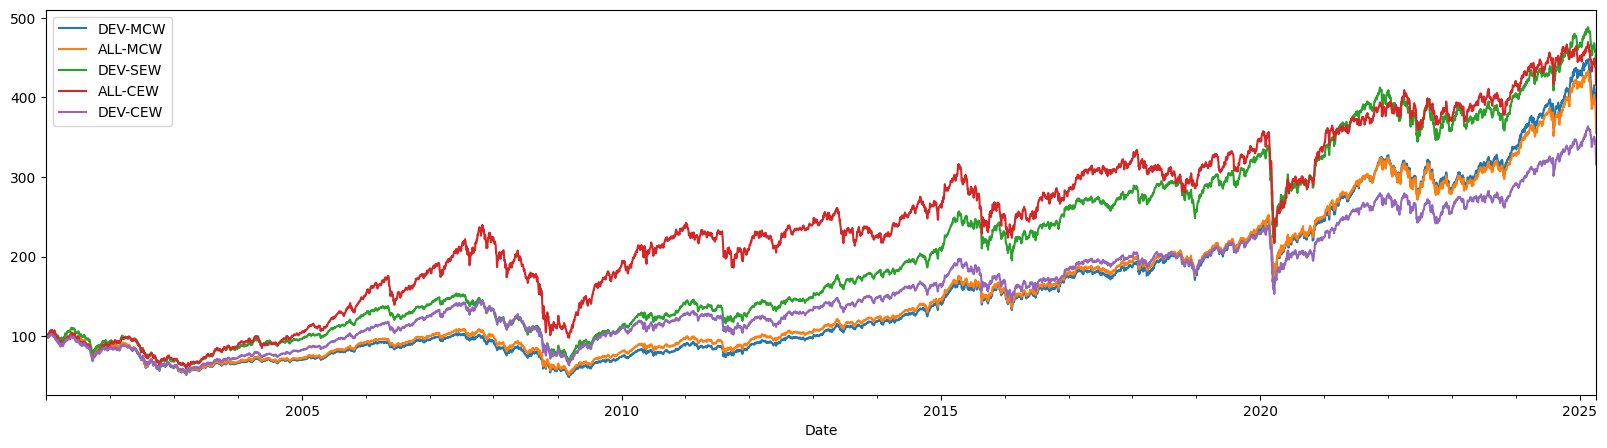

In [6]:
(100*dati/dati.iloc[0]).plot(figsize=(20,5));

## Rendimenti e volatilità su più anni

Attenzione al EW geografico che non possiamo cosi come lo abbiamo nei "dati" perché altrimenti stiamo supponendo un ribilanciamento giornaliero che un investitore ovviamente non fa.

Per EW geografico dobbiamo ricalcolare l'indice a seconda del periodo di detenzione. Lascio comunque EW per indicare un EW geografico ribilanciato giornalmente, ma aggiungo EW nr (non ribilanciato).

In [7]:
VERBOSE = False

for starting_year in [2000, 2003, 2008, 2018]:
    starting_date = dati.query(f"index >= '{starting_year}-01-01'").index[0].date()
    descr = {}
    holding_years = [1,2,3,7,12]
    for anni in holding_years:
        rendimenti =            (( 1 +        dati.loc[starting_date:].pct_change(anni*261,fill_method=None) )**(1/anni) - 1)
        rendimenti["ALL-CEW"] = (( 1 +     dati_ew.loc[starting_date:].pct_change(anni*261,fill_method=None) )**(1/anni) - 1).mean(axis=1).astype(float) # here there is some non-float values messing everything up
        rendimenti["DEV-CEW"] = (( 1 + dati_ew_dev.loc[starting_date:].pct_change(anni*261,fill_method=None) )**(1/anni) - 1).mean(axis=1).astype(float)
        if VERBOSE:
            rendimenti.dropna().plot(figsize=(15,6), title=f"Rendimenti {anni} anni", legend=True, grid=True)
            plt.show()
        descr[anni] = (100*rendimenti).describe(include="all")
        if VERBOSE:
            display(descr[anni])
        if anni==7 and starting_year==2000:
            print("Table for Comparison with Coletti @ https://youtu.be/bjZq9Fq5Wtg?t=1525")
            print("Note: sligtly different because the final date is different than the video, but `min` and `max` should be EXACTLY the same unless some very outlier pariod happened in the meanwhile")
            display(descr[anni])
            
    descr_df = pd.DataFrame()
    for y in descr:
        df = (
            descr[y]
            .reset_index()
            .melt(id_vars='index', var_name='col', value_name='value')
            .assign(years=y)
            .query("index.isin(['mean', 'std'])")
            .pivot(index=["col", "years"], columns="index", values="value").reset_index()
        )
        descr_df = pd.concat([descr_df, df], axis=0)
    descr_df.dropna(inplace=True) # Note that in certain case the total reference period is < holding period: discard it!
    holding_years_notna = descr_df.years.unique().astype(str).tolist()
    if VERBOSE:
        display(descr_df)
        
    fig = px.line(
        descr_df.astype({"years": str}), 
        x="std", 
        y="mean", 
        color="col", 
        markers=True,
        hover_data={"mean": ":.2f", "std": ":.2f", "years": True},
        symbol="years",
    ).update_layout(
        width=800, 
        height=400,
        title=f"Backtesting <b><span style='color:red'>{starting_date}</span></b> - {dati.index[-1].date()} for holding periods of {','.join(holding_years_notna)} years (EUR)",
        xaxis_title="Standard Dev (%)",
        yaxis_title="Average Yield (%)",
        legend_title="Holding period (years)",
        yaxis_range=[5, 16],
        xaxis_range=[0, 20],
    )
    fig.show()

Table for Comparison with Coletti @ https://youtu.be/bjZq9Fq5Wtg?t=1525
Note: sligtly different because the final date is different than the video, but `min` and `max` should be EXACTLY the same unless some very outlier pariod happened in the meanwhile


,DEV-MCW,ALL-MCW,DEV-SEW,ALL-CEW,DEV-CEW
count,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000
mean,7.570122,7.374762,7.522354,5.713791,5.787617
std,5.450726,4.878721,3.995689,2.978735,2.865072
min,-8.517084,-7.911056,-5.547459,-1.481897,-5.166011
25%,3.054872,3.442274,4.570376,4.089461,3.559287
50%,10.031454,9.407081,7.364281,5.368907,6.709670
75%,12.094202,11.325741,10.656722,6.691232,7.689662
max,17.465042,16.833628,18.751809,15.778459,14.161776


## Conclusion
- The thesis of Coletti that MCW and ECW have lower volatily (stdev) and sometimes even optimal pareto return/volatility is particularly biased in the choice of 3-7 years of holding and data from 2000-12-29
- He anyways has a point that standard volatility computed as montly standard detivation is misleading for the investor who has a clear minimal horizon UNLESS we factor in the risk of urgent unexpected liquidation